# Machine Learning Lab 5 — Linear Regression: Predicting House Prices

**Name:** Muhammad Talha   <br>
**CMS ID:** 023-24-0269   <br>
**Section:** H <br>
**GitHub:**  github.com/talha-devx <br>
**Kaggle:** https://www.kaggle.com/dvlprtalha   <br>
**Dataset:** House Prices — Advanced Regression Techniques   <br>
**Dataset Source:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data 

## 1. Problem Definition

The objective of this lab is to build a Multiple Linear Regression model to predict house sale prices using different characteristics of houses.

The target variable is **SalePrice**, while house-related attributes such as living area, overall quality, year built, number of bathrooms, garage capacity, and neighborhood will be used as input features.

Since SalePrice is a continuous numerical value, this is a regression problem.

### Task 1 — Load and Inspect the Dataset

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('train.csv')
print("DataSet Shape:", df.shape)
df.head()

DataSet Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [46]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


#### Dataset Exploration Interpretation

The dataset contains 1,460 houses and 81 columns. The columns include both numerical and categorical variables, so some preprocessing will be required before training the Linear Regression model.

The target variable, SalePrice, has an average value of approximately $180,921. House prices range from $34,900 to $755,000, showing considerable variation in the dataset.

### Task 2 — Identify Features and Target

In [47]:
numerical_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr'
]

categorical_features = [
    'Neighborhood',
    'HouseStyle',
    'KitchenQual',
    'ExterQual',
    'CentralAir'
]

target = 'SalePrice'

print("Dependent Variable:")
print(target)

print("\nNumerical Independent Variables:")
print(numerical_features)

print("\nCategorical Independent Variables:")
print(categorical_features)

Dependent Variable:
SalePrice

Numerical Independent Variables:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', 'BedroomAbvGr']

Categorical Independent Variables:
['Neighborhood', 'HouseStyle', 'KitchenQual', 'ExterQual', 'CentralAir']


### Task 3 — Regression Problem

This is a regression problem because the target variable, **SalePrice**, is a continuous numerical value rather than a fixed category or class.

Therefore, the model will be evaluated using regression metrics such as **MAE, MSE, RMSE, and R²** instead of classification metrics such as accuracy.

## 4. Data Preparation

The selected features contain both numerical and categorical variables. Before training the Linear Regression model, the data must be converted into a completely numerical format and missing values must be handled.

For numerical features, missing values will be replaced with the **median** of the corresponding column. The median is used because it is less affected by extreme values.

For categorical features, missing values will be replaced with the **mode**, which represents the most frequently occurring category.

Categorical variables with multiple categories will then be converted using **one-hot encoding** because these categories do not have a natural numerical order.

In [48]:
# Selected numerical features
numerical_features = [
    'OverallQual',
    'GrLivArea',
    'TotalBsmtSF',
    'GarageCars',
    'YearBuilt',
    'FullBath',
    'BedroomAbvGr'
]

# Selected categorical features
categorical_features = [
    'Neighborhood',
    'HouseStyle',
    'KitchenQual',
    'ExterQual',
    'CentralAir'
]

# Combine all selected features
selected_features = numerical_features + categorical_features

# Independent variables
X = df[selected_features].copy()

# Dependent / target variable
y = df['SalePrice'].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (1460, 12)
y shape: (1460,)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,BedroomAbvGr,Neighborhood,HouseStyle,KitchenQual,ExterQual,CentralAir
0,7,1710,856,2,2003,2,3,CollgCr,2Story,Gd,Gd,Y
1,6,1262,1262,2,1976,2,3,Veenker,1Story,TA,TA,Y
2,7,1786,920,2,2001,2,3,CollgCr,2Story,Gd,Gd,Y
3,7,1717,756,3,1915,1,3,Crawfor,2Story,Gd,TA,Y
4,8,2198,1145,3,2000,2,4,NoRidge,2Story,Gd,Gd,Y


In [49]:
# Check missing values before preprocessing
print("Missing values before preprocessing:")
print(X.isnull().sum())

Missing values before preprocessing:
OverallQual     0
GrLivArea       0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
FullBath        0
BedroomAbvGr    0
Neighborhood    0
HouseStyle      0
KitchenQual     0
ExterQual       0
CentralAir      0
dtype: int64


#### Missing-Value Handling

Missing values were checked for all selected features. Numerical missing values are handled using the median of each numerical column, while categorical missing values are handled using the mode of each categorical column.

This ensures that missing observations do not cause errors when training the Linear Regression model.

In [50]:
# Fill missing numerical values with median
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

In [51]:
# Fill missing categorical values with mode
for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

In [52]:
# One-hot encode categorical features
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("Shape after one-hot encoding:", X.shape)

X.head()

Shape after one-hot encoding: (1460, 45)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,BedroomAbvGr,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,CentralAir_Y
0,7,1710,856,2,2003,2,3,0,0,0,...,1,0,0,0,1,0,0,1,0,1
1,6,1262,1262,2,1976,2,3,0,0,0,...,0,0,0,0,0,1,0,0,1,1
2,7,1786,920,2,2001,2,3,0,0,0,...,1,0,0,0,1,0,0,1,0,1
3,7,1717,756,3,1915,1,3,0,0,0,...,1,0,0,0,1,0,0,0,1,1
4,8,2198,1145,3,2000,2,4,0,0,0,...,1,0,0,0,1,0,0,1,0,1


In [53]:
print("Total missing values:", X.isnull().sum().sum())

print("\nData types:")
print(X.dtypes)

print("\nAll columns numeric:", 
      all(pd.api.types.is_numeric_dtype(X[col]) for col in X.columns))

Total missing values: 0

Data types:
OverallQual             int64
GrLivArea               int64
TotalBsmtSF             int64
GarageCars              int64
YearBuilt               int64
FullBath                int64
BedroomAbvGr            int64
Neighborhood_Blueste    int64
Neighborhood_BrDale     int64
Neighborhood_BrkSide    int64
Neighborhood_ClearCr    int64
Neighborhood_CollgCr    int64
Neighborhood_Crawfor    int64
Neighborhood_Edwards    int64
Neighborhood_Gilbert    int64
Neighborhood_IDOTRR     int64
Neighborhood_MeadowV    int64
Neighborhood_Mitchel    int64
Neighborhood_NAmes      int64
Neighborhood_NPkVill    int64
Neighborhood_NWAmes     int64
Neighborhood_NoRidge    int64
Neighborhood_NridgHt    int64
Neighborhood_OldTown    int64
Neighborhood_SWISU      int64
Neighborhood_Sawyer     int64
Neighborhood_SawyerW    int64
Neighborhood_Somerst    int64
Neighborhood_StoneBr    int64
Neighborhood_Timber     int64
Neighborhood_Veenker    int64
HouseStyle_1.5Unf       int64
Hou

#### Data Preparation Interpretation

The dataset was prepared successfully for Linear Regression. Missing numerical values were handled using median imputation, while missing categorical values were handled using mode imputation.

One-hot encoding was applied to the categorical features because variables such as Neighborhood and HouseStyle contain nominal categories without a meaningful numerical order. The first category of each categorical variable was dropped to avoid redundant dummy variables.

After preprocessing, all input features are numerical and there are no remaining missing values. The dataset is therefore ready for the train/test split and model training.

### Task 5 — Verify Prepared Data

Before training the model, the prepared feature matrix was checked to ensure that all features are numerical and that no missing values remain.

This is necessary because scikit-learn's Linear Regression model requires numerical input without missing values.

In [54]:
# Check for remaining missing values
total_missing = X.isnull().sum().sum()

# Check whether all columns are numeric
all_numeric = all(
    pd.api.types.is_numeric_dtype(X[col])
    for col in X.columns
)

print("Total missing values in X:", total_missing)
print("All features are numeric:", all_numeric)
print("Final shape of X:", X.shape)

Total missing values in X: 0
All features are numeric: True
Final shape of X: (1460, 45)


#### Interpretation

The prepared feature matrix contains no missing values, and all features are now numerical. The number of columns increased after one-hot encoding because categorical variables were converted into multiple binary dummy variables.

Therefore, the dataset is ready to be split into training and testing sets.

### Task 6 — Train/Test Split

The prepared dataset is divided into training and testing sets using an 80/20 split.

80% of the data is used to train the Linear Regression model, while the remaining 20% is kept unseen during training and is used to evaluate how well the model generalizes to new data.

A fixed `random_state` is used to make the split reproducible.

In [55]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 45)
X_test shape: (292, 45)
y_train shape: (1168,)
y_test shape: (292,)


#### Train/Test Split Interpretation

The dataset was divided using an 80/20 train-test split. The training set contains 1,168 houses, while the testing set contains 292 houses.

The model will learn its coefficients using only the training data. The testing data will then provide an independent evaluation of the model's performance on previously unseen houses.

### Task 7 — Train the Linear Regression Model

A Multiple Linear Regression model is trained using all of the prepared features.

Multiple Linear Regression is appropriate because the house price is being predicted using several independent variables simultaneously, including house quality, living area, basement area, garage capacity, year built, and categorical house characteristics.

In [56]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


#### Model Training Interpretation

The Linear Regression model was successfully trained using the training dataset. During training, the model estimates an intercept and coefficients that describe the relationship between the selected house features and SalePrice.

These learned parameters will now be used to predict prices for houses in the unseen testing set.

### Task 8 — Generate Predictions

The trained Linear Regression model is now used to predict SalePrice for the houses in the testing set.

These predictions can be compared with the actual SalePrice values to examine how closely the model estimates house prices.

In [57]:
# Generate predictions on the test set
y_pred = model.predict(X_test)

print("Number of predictions:", len(y_pred))

# Display first five predictions
print("\nFirst 5 predicted prices:")
print(y_pred[:5])

Number of predictions: 292

First 5 predicted prices:
[136398.18196509 323589.99143888 116716.25096807 173205.04462799
 305724.55558036]


In [58]:
# actual vs predicted comparison table
comparison = pd.DataFrame({
    'Actual SalePrice': y_test.values,
    'Predicted SalePrice': y_pred
})

# Round predicted prices for readability
comparison['Predicted SalePrice'] = comparison[
    'Predicted SalePrice'
].round(2)

# Display first 10 test houses
comparison.head(10)

,Actual SalePrice,Predicted SalePrice
0,154500,136398.18
1,325000,323589.99
2,115000,116716.25
3,159000,173205.04
4,315500,305724.56
5,75500,69029.76
6,311500,230881.78
7,146000,146588.01
8,84500,68681.47
9,135500,117854.25


In [59]:
comparison['Difference'] = (
    comparison['Actual SalePrice']
    - comparison['Predicted SalePrice']
).round(2)

comparison.head(10)

,Actual SalePrice,Predicted SalePrice,Difference
0,154500,136398.18,18101.82
1,325000,323589.99,1410.01
2,115000,116716.25,-1716.25
3,159000,173205.04,-14205.04
4,315500,305724.56,9775.44
5,75500,69029.76,6470.24
6,311500,230881.78,80618.22
7,146000,146588.01,-588.01
8,84500,68681.47,15818.53
9,135500,117854.25,17645.75


### Task 9 Coefficients and Intercept

After training the Linear Regression model, its intercept and coefficients can be examined to understand how each feature is associated with the predicted house price.

A positive coefficient indicates that an increase in that feature is associated with an increase in predicted SalePrice, while a negative coefficient indicates an association with a decrease in predicted SalePrice, holding all other features constant.

For one-hot encoded categorical variables, the coefficient represents the estimated price difference between that category and the reference category that was removed during one-hot encoding.

In [60]:
# Extract the intercept
intercept = model.intercept_

print(f"Model Intercept: ${intercept:,.2f}")

Model Intercept: $-318,210.59


In [61]:
# Create coefficient table
coefficient_table = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

# Round coefficients for readability
coefficient_table['Coefficient'] = coefficient_table['Coefficient'].round(2)

coefficient_table

,Feature,Coefficient
0,OverallQual,12090.63
1,GrLivArea,57.85
2,TotalBsmtSF,4.12
3,GarageCars,11104.70
4,YearBuilt,174.14
5,FullBath,778.02
6,BedroomAbvGr,-2179.04
7,Neighborhood_Blueste,-1955.04
8,Neighborhood_BrDale,-3536.61
9,Neighborhood_BrkSide,21082.06


In [62]:
def interpret_coefficient(feature, coefficient):
    
    # Numerical features
    numerical_descriptions = {
        'OverallQual': 'one-unit increase in overall quality rating',
        'GrLivArea': 'one additional square foot of above-ground living area',
        'TotalBsmtSF': 'one additional square foot of basement area',
        'GarageCars': 'space for one additional car in the garage',
        'YearBuilt': 'one-year increase in the year the house was built',
        'FullBath': 'one additional full bathroom',
        'BedroomAbvGr': 'one additional above-ground bedroom'
    }
    
    if feature in numerical_descriptions:
        change = numerical_descriptions[feature]
        
        if coefficient >= 0:
            return (
                f"A {change} is associated with an increase of "
                f"approximately ${abs(coefficient):,.2f} in predicted "
                f"SalePrice, holding other features constant."
            )
        else:
            return (
                f"A {change} is associated with a decrease of "
                f"approximately ${abs(coefficient):,.2f} in predicted "
                f"SalePrice, holding other features constant."
            )
    
    # One-hot encoded categorical features
    if '_' in feature:
        original_feature, category = feature.split('_', 1)
        
        if coefficient >= 0:
            return (
                f"Being in category '{category}' for {original_feature} "
                f"is associated with approximately ${abs(coefficient):,.2f} "
                f"higher predicted SalePrice than the reference category, "
                f"holding other features constant."
            )
        else:
            return (
                f"Being in category '{category}' for {original_feature} "
                f"is associated with approximately ${abs(coefficient):,.2f} "
                f"lower predicted SalePrice than the reference category, "
                f"holding other features constant."
            )
    
    return "Coefficient represents the estimated effect on SalePrice."


# Generate interpretation for every coefficient
coefficient_table['Interpretation'] = coefficient_table.apply(
    lambda row: interpret_coefficient(
        row['Feature'],
        row['Coefficient']
    ),
    axis=1
)

coefficient_table

,Feature,Coefficient,Interpretation
0,OverallQual,12090.63,"A one-unit increase in overall quality rating is associated with an increase of approximately $12,090.63 in predicted SalePrice, holding other features constant."
1,GrLivArea,57.85,"A one additional square foot of above-ground living area is associated with an increase of approximately $57.85 in predicted SalePrice, holding other features constant."
2,TotalBsmtSF,4.12,"A one additional square foot of basement area is associated with an increase of approximately $4.12 in predicted SalePrice, holding other features constant."
3,GarageCars,11104.70,"A space for one additional car in the garage is associated with an increase of approximately $11,104.70 in predicted SalePrice, holding other features constant."
4,YearBuilt,174.14,"A one-year increase in the year the house was built is associated with an increase of approximately $174.14 in predicted SalePrice, holding other features constant."
5,FullBath,778.02,"A one additional full bathroom is associated with an increase of approximately $778.02 in predicted SalePrice, holding other features constant."
6,BedroomAbvGr,-2179.04,"A one additional above-ground bedroom is associated with a decrease of approximately $2,179.04 in predicted SalePrice, holding other features constant."
7,Neighborhood_Blueste,-1955.04,"Being in category 'Blueste' for Neighborhood is associated with approximately $1,955.04 lower predicted SalePrice than the reference category, holding other features constant."
8,Neighborhood_BrDale,-3536.61,"Being in category 'BrDale' for Neighborhood is associated with approximately $3,536.61 lower predicted SalePrice than the reference category, holding other features constant."
9,Neighborhood_BrkSide,21082.06,"Being in category 'BrkSide' for Neighborhood is associated with approximately $21,082.06 higher predicted SalePrice than the reference category, holding other features constant."


In [63]:
# Show reference category for each categorical feature
print("Reference categories used by one-hot encoding:\n")

for col in categorical_features:
    categories = sorted(df[col].dropna().unique())
    print(f"{col}: {categories[0]}")

Reference categories used by one-hot encoding:

Neighborhood: Blmngtn
HouseStyle: 1.5Fin
KitchenQual: Ex
ExterQual: Ex
CentralAir: N


### Task - 10 Intercept Interpretation

The model intercept represents the predicted SalePrice when all numerical features and all dummy variables are equal to zero.

However, the intercept does not have a very meaningful real-world interpretation in this dataset. Setting variables such as OverallQual, GrLivArea, TotalBsmtSF, GarageCars, YearBuilt, FullBath, and BedroomAbvGr to zero would describe an unrealistic house.

Therefore, the intercept is mathematically necessary for the Linear Regression equation, but it should not be interpreted as the realistic price of an actual house.

In [64]:
# Final clean coefficient table
final_coefficient_table = coefficient_table[
    ['Feature', 'Coefficient', 'Interpretation']
]

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

final_coefficient_table

,Feature,Coefficient,Interpretation
0,OverallQual,12090.63,"A one-unit increase in overall quality rating is associated with an increase of approximately $12,090.63 in predicted SalePrice, holding other features constant."
1,GrLivArea,57.85,"A one additional square foot of above-ground living area is associated with an increase of approximately $57.85 in predicted SalePrice, holding other features constant."
2,TotalBsmtSF,4.12,"A one additional square foot of basement area is associated with an increase of approximately $4.12 in predicted SalePrice, holding other features constant."
3,GarageCars,11104.70,"A space for one additional car in the garage is associated with an increase of approximately $11,104.70 in predicted SalePrice, holding other features constant."
4,YearBuilt,174.14,"A one-year increase in the year the house was built is associated with an increase of approximately $174.14 in predicted SalePrice, holding other features constant."
5,FullBath,778.02,"A one additional full bathroom is associated with an increase of approximately $778.02 in predicted SalePrice, holding other features constant."
6,BedroomAbvGr,-2179.04,"A one additional above-ground bedroom is associated with a decrease of approximately $2,179.04 in predicted SalePrice, holding other features constant."
7,Neighborhood_Blueste,-1955.04,"Being in category 'Blueste' for Neighborhood is associated with approximately $1,955.04 lower predicted SalePrice than the reference category, holding other features constant."
8,Neighborhood_BrDale,-3536.61,"Being in category 'BrDale' for Neighborhood is associated with approximately $3,536.61 lower predicted SalePrice than the reference category, holding other features constant."
9,Neighborhood_BrkSide,21082.06,"Being in category 'BrkSide' for Neighborhood is associated with approximately $21,082.06 higher predicted SalePrice than the reference category, holding other features constant."


### Residual Analysis

Residuals represent the difference between the actual and predicted house prices:

**Residual = Actual SalePrice − Predicted SalePrice**

A good regression model should ideally produce residuals that are randomly scattered around zero without a clear systematic pattern.

Two plots are used below: a residuals-vs-predicted-values plot and a histogram showing the distribution of residuals.

In [65]:
# Calculate residuals
residuals = y_test.values - y_pred

# Display first 10 residuals
residual_table = pd.DataFrame({
    'Actual SalePrice': y_test.values,
    'Predicted SalePrice': y_pred,
    'Residual': residuals
})

residual_table = residual_table.round(2)
residual_table.head(10)

,Actual SalePrice,Predicted SalePrice,Residual
0,154500,136398.18,18101.82
1,325000,323589.99,1410.01
2,115000,116716.25,-1716.25
3,159000,173205.04,-14205.04
4,315500,305724.56,9775.44
5,75500,69029.76,6470.24
6,311500,230881.78,80618.22
7,146000,146588.01,-588.01
8,84500,68681.47,15818.53
9,135500,117854.25,17645.75


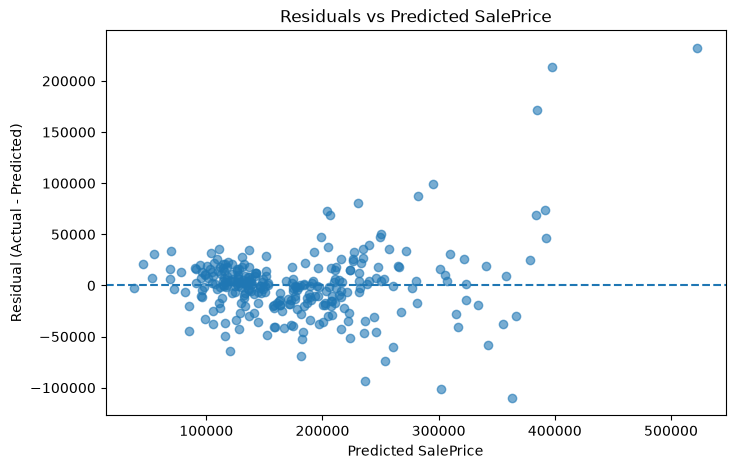

In [66]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals, alpha=0.6)

# Horizontal line at zero
plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted SalePrice')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residuals vs Predicted SalePrice')

plt.show()

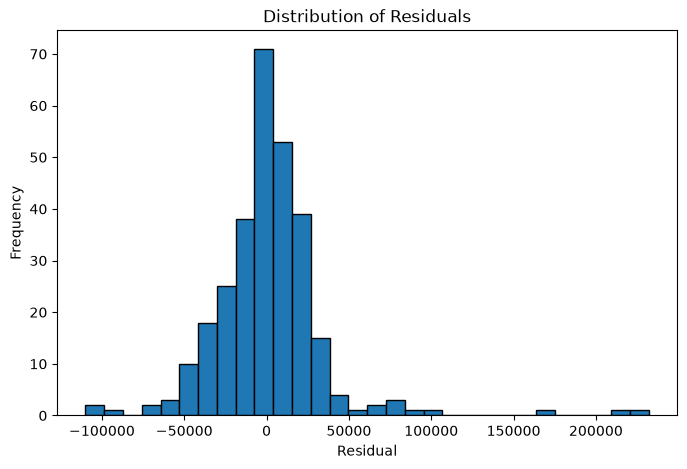

In [67]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=30, edgecolor='black')

plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.show()

### Task 12 - Regression Metrics

The performance of the Linear Regression model is evaluated using four standard regression metrics:

- **MAE (Mean Absolute Error):** Average absolute difference between actual and predicted prices.
- **MSE (Mean Squared Error):** Average squared prediction error, which gives greater weight to large errors.
- **RMSE (Root Mean Squared Error):** Square root of MSE, expressed in the same unit as SalePrice.
- **R² (Coefficient of Determination):** Measures how much of the variation in SalePrice is explained by the model.

In [68]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Calculate regression metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.2f}")
print(f"MSE:   {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:    {r2:.4f}")

MAE:  $21,120.13
MSE:   1,171,080,232.75
RMSE: $34,221.05
R²:    0.8473


In [69]:
metrics_table = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [mae, mse, rmse, r2]
})

metrics_table

,Metric,Value
0,MAE,2.112013e+04
1,MSE,1.171080e+09
2,RMSE,3.422105e+04
3,R²,8.473233e-01


In [70]:
formatted_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [
        f"${mae:,.2f}",
        f"{mse:,.2f}",
        f"${rmse:,.2f}",
        f"{r2:.4f}"
    ]
})

formatted_metrics

,Metric,Value
0,MAE,"$21,120.13"
1,MSE,"1,171,080,232.75"
2,RMSE,"$34,221.05"
3,R²,0.8473


#### Model Performance Interpretation

The model achieved an **MAE of approximately $21,120.13**, meaning that the predicted house prices differ from the actual house prices by about $21,120 on average.

The **RMSE is approximately $34,221.05**. Since RMSE gives more weight to large prediction errors, its higher value compared with MAE suggests that some houses have relatively large prediction errors.

The model achieved an **R² score of 0.8473**, meaning that approximately **84.73% of the variation in SalePrice** in the test set is explained by the selected features in the Linear Regression model.

Overall, the model explains a substantial portion of the variation in house prices, although some prediction errors remain, particularly for houses that are more difficult for the linear model to estimate.

### Task 13 — Understanding the Regression Metrics

**MAE (Mean Absolute Error):**  
The MAE of **$21,120.13** means that, on average, the model's predicted house price differs from the actual price by about $21,120. It gives a simple idea of the typical prediction error.

**MSE (Mean Squared Error):**  
The MSE is approximately **1.171 billion**. It calculates the average of the squared prediction errors, so larger mistakes receive a much greater penalty. Since the value is in squared dollar units, it is not very intuitive to explain directly.

**RMSE (Root Mean Squared Error):**  
The RMSE of **$34,221.05** represents prediction error in the same unit as SalePrice. It gives more importance to large prediction errors than MAE. The fact that RMSE is noticeably higher than MAE suggests that the model makes some relatively large errors for certain houses.

**R² (Coefficient of Determination):**  
The R² score is **0.8473**, which means that the model explains approximately **84.73% of the variation in house prices** in the test data. The remaining variation is not explained by the current Linear Regression model and selected features.

##### Metric for a Non-Technical Stakeholder
I would show **MAE** to a non-technical stakeholder because it is the easiest metric to understand in real-world terms. I can simply explain that the model's house-price predictions are off by approximately **$21,120 on average**. This is more intuitive than MSE, RMSE, or R² for someone without a machine-learning background.

### Task 14 — Training vs Testing Performance

To evaluate how well the model generalizes, its performance on the training data is compared with its performance on the unseen testing data.

The same four regression metrics — MAE, MSE, RMSE, and R² — are calculated for both datasets. A large difference between training and testing performance may indicate overfitting.

In [71]:
# Generate predictions for the training set
y_train_pred = model.predict(X_train)

print("Number of training predictions:", len(y_train_pred))

Number of training predictions: 1168


In [72]:
# Calculate training-set metrics
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Training MAE:  ${train_mae:,.2f}")
print(f"Training MSE:   {train_mse:,.2f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Training R²:    {train_r2:.4f}")

Training MAE:  $20,258.89
Training MSE:   1,035,089,788.68
Training RMSE: $32,172.81
Training R²:    0.8265


In [73]:
comparison_metrics = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    
    'Training': [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    
    'Testing': [
        mae,
        mse,
        rmse,
        r2
    ]
})

comparison_metrics

,Metric,Training,Testing
0,MAE,2.025889e+04,2.112013e+04
1,MSE,1.035090e+09,1.171080e+09
2,RMSE,3.217281e+04,3.422105e+04
3,R²,8.264597e-01,8.473233e-01


In [74]:
formatted_comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    
    'Training Performance': [
        f"${train_mae:,.2f}",
        f"{train_mse:,.2f}",
        f"${train_rmse:,.2f}",
        f"{train_r2:.4f}"
    ],
    
    'Testing Performance': [
        f"${mae:,.2f}",
        f"{mse:,.2f}",
        f"${rmse:,.2f}",
        f"{r2:.4f}"
    ]
})

formatted_comparison

,Metric,Training Performance,Testing Performance
0,MAE,"$20,258.89","$21,120.13"
1,MSE,"1,035,089,788.68","1,171,080,232.75"
2,RMSE,"$32,172.81","$34,221.05"
3,R²,0.8265,0.8473


In [75]:
print("Training vs Testing Difference")
print("--------------------------------")

print(f"MAE difference:  ${mae - train_mae:,.2f}")
print(f"RMSE difference: ${rmse - train_rmse:,.2f}")
print(f"R² difference:   {train_r2 - r2:.4f}")

Training vs Testing Difference
--------------------------------
MAE difference:  $861.24
RMSE difference: $2,048.24
R² difference:   -0.0209


### Task 15 — Overfitting and Generalization

The training and testing performances are relatively close. The training MAE is approximately **$20,258.89**, compared with a testing MAE of **$21,120.13**, giving a difference of only about **$861.24**. Similarly, the training RMSE is approximately **$32,172.81**, while the testing RMSE is **$34,221.05**.

The training R² is **0.8265**, while the testing R² is **0.8473**. Interestingly, the testing R² is slightly higher than the training R². This can occur because of the particular random train/test split and does not by itself indicate a problem.

A large gap where training performance is much better than testing performance would suggest overfitting. In this case, the training and testing results are quite similar, so there is **no strong evidence of overfitting**. The results suggest that the Linear Regression model generalizes reasonably well to unseen house data.

### Task 16 — Find the Largest Coefficients
Model Interpretation — Most Influential Features

The coefficients of the Linear Regression model can be examined to identify features that have strong estimated effects on predicted house prices.

However, coefficient magnitudes must be interpreted carefully because the features are measured on different scales. For example, GrLivArea is measured in square feet, while OverallQual is measured using a rating scale and categorical dummy variables are binary (0 or 1). Therefore, raw coefficient magnitudes are not a perfect measure of overall feature importance.

In [76]:
# Create a table sorted by absolute coefficient magnitude
influential_features = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

influential_features['Absolute Coefficient'] = (
    influential_features['Coefficient'].abs()
)

influential_features = influential_features.sort_values(
    by='Absolute Coefficient',
    ascending=False
)

# Display top 10
influential_features.head(10)

,Feature,Coefficient,Absolute Coefficient
21,Neighborhood_NoRidge,80050.870664,80050.870664
28,Neighborhood_StoneBr,65256.431457,65256.431457
30,Neighborhood_Veenker,59672.212559,59672.212559
22,Neighborhood_NridgHt,56659.760270,56659.760270
10,Neighborhood_ClearCr,53780.402904,53780.402904
40,KitchenQual_TA,-44978.921706,44978.921706
12,Neighborhood_Crawfor,44844.853871,44844.853871
38,KitchenQual_Fa,-41274.542280,41274.542280
29,Neighborhood_Timber,38495.462282,38495.462282
39,KitchenQual_Gd,-35858.998655,35858.998655


In [77]:
top_3_features = influential_features.head(3)

top_3_features

,Feature,Coefficient,Absolute Coefficient
21,Neighborhood_NoRidge,80050.870664,80050.870664
28,Neighborhood_StoneBr,65256.431457,65256.431457
30,Neighborhood_Veenker,59672.212559,59672.212559


In [78]:
for _, row in top_3_features.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"

    print(
        f"{row['Feature']}: "
        f"${row['Coefficient']:,.2f} "
        f"({direction} predicted SalePrice)"
    )

Neighborhood_NoRidge: $80,050.87 (increases predicted SalePrice)
Neighborhood_StoneBr: $65,256.43 (increases predicted SalePrice)
Neighborhood_Veenker: $59,672.21 (increases predicted SalePrice)


Most Influential Features

Based on the absolute magnitudes of the model coefficients, the three features with the largest estimated effects are **Neighborhood_NoRidge, Neighborhood_StoneBr, and Neighborhood_Veenker**.

1. **Neighborhood_NoRidge** has a coefficient of approximately **+$80,050.87**. This means that a house located in NoRidge is associated with a predicted SalePrice about **$80,051 higher than the reference neighborhood**, holding all other features constant.

2. **Neighborhood_StoneBr** has a coefficient of approximately **+$65,256.43**. This indicates that a house located in StoneBr is associated with a predicted SalePrice about **$65,256 higher than the reference neighborhood**, holding the other features constant.

3. **Neighborhood_Veenker** has a coefficient of approximately **+$59,672.21**. This means that being located in Veenker is associated with a predicted SalePrice about **$59,672 higher than the reference neighborhood**, while keeping the other variables constant.

These results suggest that neighborhood has a strong association with predicted house prices in this model. However, the raw coefficient magnitudes should not be treated as a perfect measure of feature importance because the features are measured on different scales. The neighborhood variables are binary dummy variables, while features such as GrLivArea are measured per square foot and YearBuilt is measured per year. Therefore, direct comparison of their raw coefficients should be made carefully.

### Task 17 — Final Model Analysis and Conclusion

The Linear Regression model performs reasonably well in predicting house prices, achieving an **R² score of 0.8473**, which means that approximately **84.73% of the variation in SalePrice** in the test data is explained by the model. The model achieved an **MAE of approximately $21,120** and an **RMSE of approximately $34,221**, showing that some houses have larger prediction errors than others. I consider **MAE the most useful metric for communicating the model's performance** because it shows the average prediction error directly in dollars and is easy to understand. Based on the raw coefficient magnitudes, **Neighborhood_NoRidge** shows the strongest estimated association, with houses in NoRidge having a predicted SalePrice approximately **$80,051 higher than the reference neighborhood**, holding the other features constant. However, coefficient magnitudes should be interpreted carefully because the features use different measurement scales, and these relationships represent associations rather than causation. A limitation of Linear Regression is that it assumes linear relationships and may not capture complex or nonlinear interactions among house characteristics. As a next step, I would try additional feature engineering and compare the results with more flexible models such as **Random Forest** to determine whether prediction errors can be reduced.

### Task 18 — Kaggle Submission

The trained Linear Regression model is applied to the Kaggle test dataset using the same feature selection, missing-value handling, and categorical encoding used during training.

The predicted SalePrice values are combined with the corresponding house IDs to create `submission.csv` in the format required by Kaggle.

In [79]:
test_df = pd.read_csv("test.csv")

print("Test dataset shape:", test_df.shape)
test_df.head()

Test dataset shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [80]:
X_kaggle = test_df[selected_features].copy()

print("X_kaggle shape:", X_kaggle.shape)
X_kaggle.head()

X_kaggle shape: (1459, 12)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,BedroomAbvGr,Neighborhood,HouseStyle,KitchenQual,ExterQual,CentralAir
0,5,896,882.0,1.0,1961,1,2,NAmes,1Story,TA,TA,Y
1,6,1329,1329.0,1.0,1958,1,3,NAmes,1Story,Gd,TA,Y
2,5,1629,928.0,2.0,1997,2,3,Gilbert,2Story,TA,TA,Y
3,6,1604,926.0,2.0,1998,2,3,Gilbert,2Story,Gd,TA,Y
4,8,1280,1280.0,2.0,1992,2,2,StoneBr,1Story,Gd,Gd,Y


In [81]:
# Fill numerical missing values using TRAINING data medians
for col in numerical_features:
    X_kaggle[col] = X_kaggle[col].fillna(df[col].median())

# Fill categorical missing values using TRAINING data modes
for col in categorical_features:
    X_kaggle[col] = X_kaggle[col].fillna(df[col].mode()[0])

print("Missing values:", X_kaggle.isnull().sum().sum())

Missing values: 0


In [82]:
X_kaggle = pd.get_dummies(
    X_kaggle,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

# Match exactly the columns used during model training
X_kaggle = X_kaggle.reindex(
    columns=X.columns,
    fill_value=0
)

print("Training features:", X.shape[1])
print("Kaggle test features:", X_kaggle.shape[1])
print("Columns match:", list(X.columns) == list(X_kaggle.columns))

Training features: 45
Kaggle test features: 45
Columns match: True


In [83]:
kaggle_predictions = model.predict(X_kaggle)

submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission shape:", submission.shape)
print("Missing values:", submission.isnull().sum().sum())

submission.head(10)

Submission shape: (1459, 2)
Missing values: 0


,Id,SalePrice
0,1461,113479.753409
1,1462,158878.706798
2,1463,164205.533206
3,1464,184135.816872
4,1465,249749.921209
5,1466,176423.631442
6,1467,168354.540615
7,1468,166410.577183
8,1469,200070.244162
9,1470,113251.242213


### Task 19 — Kaggle Submission Result

The final `submission.csv` file was successfully submitted to the Kaggle **House Prices - Advanced Regression Techniques** competition.

- **Public Kaggle Score:** 0.16458
- **Model:** Linear Regression
- **Submission Status:** Successful
- **Leaderboard Rank:** 2591

The submission process helped me understand how a trained machine learning model can be used to generate predictions for completely unseen data and submit them to a real competition. The final Kaggle score of **0.16458** provides an external evaluation of the model and shows that there is still room for improvement through better feature engineering and more advanced regression models.